<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/ExercicioPratica1.5/Estudo_de_Caso_%E2%80%94_An%C3%A1lise_de_Engajamento_em_Plataforma_de_Streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 27.1 MB/s eta 0:00:00


In [2]:
import pypdf
import pandas as pd

pdf_path = '/content/Exercício Prático 3_ Estudo de Caso — Análise de Engajamento em Plataforma de Streaming.pdf'
csv_path = '/content/streamdata_usuarios.csv'

# Read the PDF file
reader = pypdf.PdfReader(pdf_path)
text = ""
for page in reader.pages:
    text += page.extract_text() + "\n"

print("Conteúdo do PDF:")
print(text[:1000]) # Print first 1000 characters to get an idea of the content

# Load the CSV file
df_usuarios = pd.read_csv(csv_path)
print("\nPrimeiras 5 linhas do arquivo CSV:")
display(df_usuarios.head())

Conteúdo do PDF:
Exercício
 
Prático
 
3:
 
Estudo
 
de
 
Caso
 
—
 
Análise
 
de
 
Engajamento
 
em
 
Plataforma
 
de
 
Streaming
 
Contexto
 
do
 
Projeto
 
Você
 
atua
 
como
 
Analista
 
de
 
Dados
 
na
 
plataforma
 
de
 
streaming
 
fictícia
 
StreamData
.
 
O
 
departamento
 
de
 
produto
 
deseja
 
entender
 
o
 
comportamento
 
dos
 
usuários
 
em
 
diferentes
 
planos
 
de
 
assinatura
 
(
Básico
,
 
Padrão
 
e
 
Premium
)
 
para
 
otimizar
 
estratégias
 
de
 
retenção
 
de
 
clientes.
 
A
 
equipe
 
de
 
engenharia
 
disponibilizou
 
um
 
extrato
 
mensal
 
em
 
formato
 
.csv
 
contendo
 
dados
 
de
 
consumo
 
e
 
satisfação
 
dos
 
usuários.
 
Objetivo
 
Geral
 
Importar
 
o
 
arquivo
 
streamdata_usuarios.csv
 
utilizando
 
a
 
biblioteca
 
pandas
,
 
processar
 
as
 
métricas
 
de
 
engajamento
 
e
 
construir
 
visualizações
 
gráficas
 
com
 
matplotlib
 
para
 
responder
 
a
 
perguntas
 
estratégicas
 
do
 
negócio.
 
Instruções
 
Detalhadas
 
por
 
Etapa
 
Etapa
 

,id_usuario,plano,horas_assistidas,dispositivo_principal,score_satisfacao,cancelou_assinatura
0,USR-0001,Básico,17.5,Smart TV,5,Não
1,USR-0002,Padrão,21.3,Smartphone,4,Não
2,USR-0003,Premium,23.9,Tablet,4,Não
3,USR-0004,Básico,53.2,Smart TV,7,Não
4,USR-0005,Padrão,61.7,Tablet,5,Sim


In [3]:
# Read the entire PDF content to get all instructions
full_pdf_text = ""
for page in reader.pages:
    full_pdf_text += page.extract_text() + "\n"

print("Conteúdo completo do PDF:")
print(full_pdf_text)


Conteúdo completo do PDF:
Exercício
 
Prático
 
3:
 
Estudo
 
de
 
Caso
 
—
 
Análise
 
de
 
Engajamento
 
em
 
Plataforma
 
de
 
Streaming
 
Contexto
 
do
 
Projeto
 
Você
 
atua
 
como
 
Analista
 
de
 
Dados
 
na
 
plataforma
 
de
 
streaming
 
fictícia
 
StreamData
.
 
O
 
departamento
 
de
 
produto
 
deseja
 
entender
 
o
 
comportamento
 
dos
 
usuários
 
em
 
diferentes
 
planos
 
de
 
assinatura
 
(
Básico
,
 
Padrão
 
e
 
Premium
)
 
para
 
otimizar
 
estratégias
 
de
 
retenção
 
de
 
clientes.
 
A
 
equipe
 
de
 
engenharia
 
disponibilizou
 
um
 
extrato
 
mensal
 
em
 
formato
 
.csv
 
contendo
 
dados
 
de
 
consumo
 
e
 
satisfação
 
dos
 
usuários.
 
Objetivo
 
Geral
 
Importar
 
o
 
arquivo
 
streamdata_usuarios.csv
 
utilizando
 
a
 
biblioteca
 
pandas
,
 
processar
 
as
 
métricas
 
de
 
engajamento
 
e
 
construir
 
visualizações
 
gráficas
 
com
 
matplotlib
 
para
 
responder
 
a
 
perguntas
 
estratégicas
 
do
 
negócio.
 
Instruções
 
Detalhadas
 
por
 
Etapa


In [4]:
import matplotlib.pyplot as plt

df_stream = df_usuarios.copy()

print("Informações do DataFrame df_stream:")
df_stream.info()

Informações do DataFrame df_stream:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_usuario             250 non-null    object 
 1   plano                  250 non-null    object 
 2   horas_assistidas       250 non-null    float64
 3   dispositivo_principal  250 non-null    object 
 4   score_satisfacao       250 non-null    int64  
 5   cancelou_assinatura    250 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 11.8+ KB


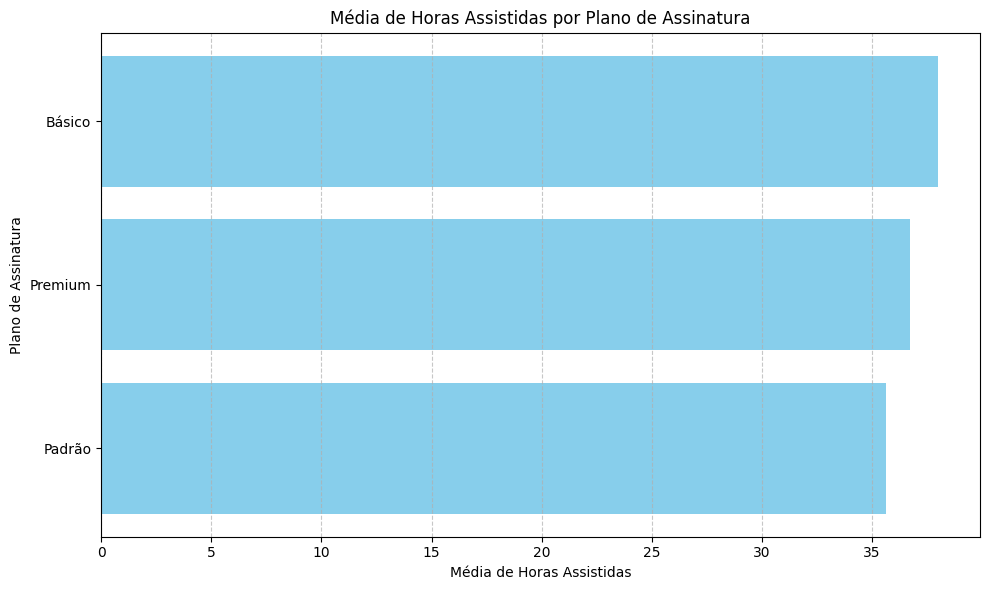

In [5]:
# Etapa 2: Média de Horas Assistidas por Plano (Gráfico de Barras Horizontal)

# 1. Agrupar o DataFrame por plano e calcular a média de horas_assistidas
media_horas_por_plano = df_stream.groupby('plano')['horas_assistidas'].mean().sort_values(ascending=True)

# 2. Crie um gráfico de barras horizontal (plt.barh)
plt.figure(figsize=(10, 6))
plt.barh(media_horas_por_plano.index, media_horas_por_plano.values, color='skyblue')

# 3. Adicione rótulos nos eixos, título explicativo e uma grade auxiliar no eixo X.
plt.xlabel('Média de Horas Assistidas')
plt.ylabel('Plano de Assinatura')
plt.title('Média de Horas Assistidas por Plano de Assinatura')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

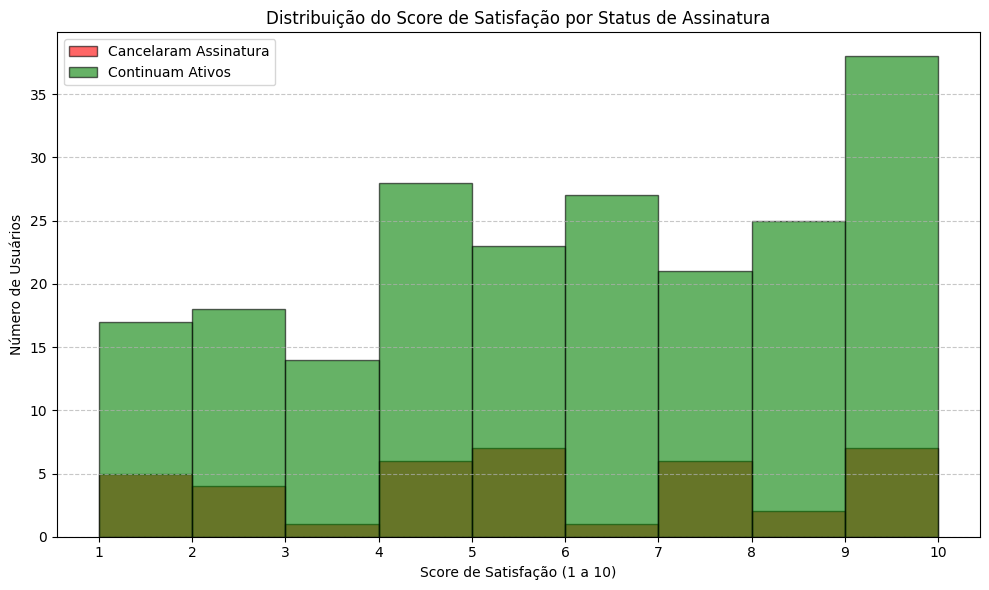

In [6]:
# Etapa 3: Relação entre Satisfação e Cancelamento (Histograma Comparativo)

# 1. Filtre os usuários em dois grupos
usuarios_cancelaram = df_stream[df_stream['cancelou_assinatura'] == 'Sim']
usuarios_ativos = df_stream[df_stream['cancelou_assinatura'] == 'Não']

# 2. Crie um gráfico com dois histogramas sobrepostos
plt.figure(figsize=(10, 6))
plt.hist(usuarios_cancelaram['score_satisfacao'], bins=range(1, 11), alpha=0.6, label='Cancelaram Assinatura', color='red', edgecolor='black')
plt.hist(usuarios_ativos['score_satisfacao'], bins=range(1, 11), alpha=0.6, label='Continuam Ativos', color='green', edgecolor='black')

# 3. Adicione rótulos nos eixos, título explicativo e uma legenda
plt.xlabel('Score de Satisfação (1 a 10)')
plt.ylabel('Número de Usuários')
plt.title('Distribuição do Score de Satisfação por Status de Assinatura')
plt.xticks(range(1, 11)) # Ensure x-axis ticks are integers from 1 to 10
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

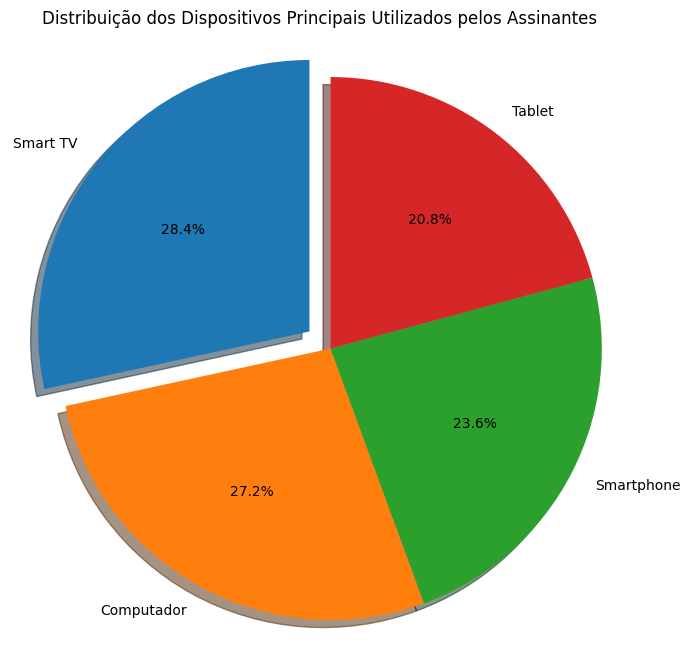

In [7]:
# Etapa 4: Distribuição dos Dispositivos Principais (Gráfico de Pizza/Rosca)

# 1. Conte o total de usuários por dispositivo_principal
dispositivo_counts = df_stream['dispositivo_principal'].value_counts()

# Identifique o dispositivo mais utilizado para 'explode'
most_used_device = dispositivo_counts.index[0]
explode = [0.1 if device == most_used_device else 0 for device in dispositivo_counts.index]

# 2. Gere um gráfico de pizza destacando a fatia do dispositivo mais utilizado.
plt.figure(figsize=(8, 8))
plt.pie(dispositivo_counts, labels=dispositivo_counts.index, autopct='%1.1f%%', startangle=90, explode=explode, shadow=True)

# Adicione um título explicativo
plt.title('Distribuição dos Dispositivos Principais Utilizados pelos Assinantes')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()